# Analyze mental from CSV IMDB film Chapter 17 Wprkshop 2

## Load module

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, GRU, Bidirectional

import os

## Check gensim package

In [2]:
gensim.__version__  # Should be 4.x.x

'4.3.3'

## Prepare pre-tain vacab

In [3]:
import gensim.downloader as api

# Load the pre-trained glove model
# The file place at C:\Users\your_username\gensim-data\glove-wiki-gigaword-100\
wv = api.load("glove-wiki-gigaword-100")  # 100-dimensional vectors

In [4]:
print("Vocabulary size:", len(wv.key_to_index))
print('Vector size:', wv.vector_size)

Vocabulary size: 400000
Vector size: 100


In [5]:
print(wv.most_similar(positive=['king','woman'],negative=['man'], topn=5))

[('queen', 0.7698540091514587), ('monarch', 0.6843381524085999), ('throne', 0.6755737066268921), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]


## Prepare data

### load csv file by direct from internet

In [6]:
# from kaggle.api.kaggle_api_extended import KaggleApi
# import os

# # Set the path to the file you'd like to load
# file_path = "../datasets/ws_17_02"
# # file_path = 'IMDB Dataset.csv'

# if os.path.exists(file_path):
#     if os.path.exists(file_path):
#         print(f"File {file_path} already exists.")
#     else:
#         api = KaggleApi()
#         api.authenticate()

#         api.dataset_download_file(
#             'lakshmi25npathi/imdb-dataset-of-50k-movie-reviews',
#             file_name='IMDB Dataset.csv',
#             path=file_path  # e.g., './data/'
#         )
#         print(f"File {file_path} downloaded successfully.")
# else:
#     print(f"File {file_path} is not a directory or does not exist.")

In [7]:
# import zipfile

# with zipfile.ZipFile(os.path.join(file_path,'IMDB Dataset.csv.zip'), 'r') as zip_ref:
#     zip_ref.extractall(file_path)

In [8]:
# print("First 5 records:", api_df.head(5))

### load from local

In [9]:
file_path = "../datasets/ws_17_02/IMDB Dataset.csv"

if not os.path.exists(file_path):
    print(f"File {file_path} does not exist. Please check the path.")
else:
    df = pd.read_csv(file_path, encoding='utf-8')
    print("Data loaded successfully.")

Data loaded successfully.


In [10]:
print("First 5 records:")
print(df.head(5))

First 5 records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


### create labels

In [11]:
df['label'] = np.where(df['sentiment'] == 'positive', 1, 0)
df.head(5)

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


### clean text

#### with BeautifulSoup (slow method)

In [12]:
from bs4 import BeautifulSoup

def remove_tag(text):
    return BeautifulSoup(text, "lxml").get_text()

df['review2'] = df['review'].apply(remove_tag)

In [13]:
df.head(5)

,review,sentiment,label,review2
0,One of the other reviewers has mentioned that ...,positive,1,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,1,A wonderful little production. The filming tec...
2,I thought this was a wonderful way to spend ti...,positive,1,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,0,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,"Petter Mattei's ""Love in the Time of Money"" is..."


#### with built-in regex for HTML tag removal (fastest)

Pros: Way faster than BeautifulSoup.

Cons: Less robust on malformed HTML, but often fine for datasets like IMDb reviews where tags are simple.

In [14]:
import re

TAG_RE = re.compile(r'<[^>]+>')

def remove_html_tags(text):
    return TAG_RE.sub('', text)

# df['review2'] = df['review'].map(remove_html_tags)

#### with str.replace directly

Even faster, vectorized operation with pandas.

Best for performance, especially with large datasets.

Downside: Still not as robust as BeautifulSoup for deeply nested or broken HTML.

In [15]:
# df['review2'] = df['review'].str.replace(r'<[^>]+>', '', regex=True)

### cut stop word

In [16]:
from gensim.parsing.preprocessing import remove_stopwords
df['review2'] = df['review2'].apply(remove_stopwords)

In [17]:
df.head(5)

,review,sentiment,label,review2
0,One of the other reviewers has mentioned that ...,positive,1,One reviewers mentioned watching 1 Oz episode ...
1,A wonderful little production. <br /><br />The...,positive,1,A wonderful little production. The filming tec...
2,I thought this was a wonderful way to spend ti...,positive,1,I thought wonderful way spend time hot summer ...
3,Basically there's a family where a little boy ...,negative,0,Basically there's family little boy (Jake) thi...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,"Petter Mattei's ""Love Time Money"" visually stu..."


### cut abbreviations and '

In [18]:
import re

CONTRACTIONS = {
    "'s" : " is", "'ll": " will", "won't": "will not",
    "n't": " not", "'re": " are", "'d": " would",
    "'m": " am", "'ve": " have"
}

def expand_contractions(text):
    pattern = re.compile('(%s)' % '|'.join(CONTRACTIONS.keys()))
    return pattern.sub(lambda x: CONTRACTIONS[x.group()], text)

df['review_clean'] = df['review2'].str.lower()
df['review_clean'] = df['review_clean'].apply(expand_contractions)
df['review_clean'] = df['review_clean'].str.replace("'", "", regex=False)
# df['review_clean'] = df['review_clean'].str.replace(r"[^\w\s]", "", regex=True)

In [19]:
df.head(5)

,review,sentiment,label,review2,review_clean
0,One of the other reviewers has mentioned that ...,positive,1,One reviewers mentioned watching 1 Oz episode ...,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,positive,1,A wonderful little production. The filming tec...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,positive,1,I thought wonderful way spend time hot summer ...,i thought wonderful way spend time hot summer ...
3,Basically there's a family where a little boy ...,negative,0,Basically there's family little boy (Jake) thi...,basically there is family little boy (jake) th...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,"Petter Mattei's ""Love Time Money"" visually stu...","petter mattei is ""love time money"" visually st..."


### tokenization

In [20]:
tk = Tokenizer()
# tk.fit_on_texts(df['review2'])
tk.fit_on_texts(df['review_clean'])

In [21]:
# tk.index_word
tk.word_index

{'i': 1,
 'is': 2,
 'the': 3,
 'movie': 4,
 'it': 5,
 'film': 6,
 'not': 7,
 'like': 8,
 'this': 9,
 'good': 10,
 'time': 11,
 'story': 12,
 'and': 13,
 'do': 14,
 'there': 15,
 'bad': 16,
 'you': 17,
 'people': 18,
 'great': 19,
 'but': 20,
 'that': 21,
 'in': 22,
 'he': 23,
 'a': 24,
 'way': 25,
 'movies': 26,
 'characters': 27,
 'think': 28,
 'watch': 29,
 'character': 30,
 'films': 31,
 'seen': 32,
 'love': 33,
 'plot': 34,
 'life': 35,
 'have': 36,
 'acting': 37,
 'best': 38,
 'know': 39,
 'little': 40,
 'one': 41,
 'if': 42,
 'man': 43,
 'all': 44,
 'better': 45,
 'end': 46,
 'are': 47,
 'scene': 48,
 'did': 49,
 'scenes': 50,
 'well': 51,
 'they': 52,
 'does': 53,
 'am': 54,
 'real': 55,
 'will': 56,
 'thing': 57,
 'watching': 58,
 'actors': 59,
 'what': 60,
 'director': 61,
 'years': 62,
 'funny': 63,
 'old': 64,
 'as': 65,
 'work': 66,
 'actually': 67,
 '10': 68,
 'so': 69,
 'makes': 70,
 'look': 71,
 'going': 72,
 'she': 73,
 'new': 74,
 'lot': 75,
 'would': 76,
 'world': 77,

In [22]:
vocab_size = len(tk.word_index) + 1  # +1 for padding token
print("Vocabulary size:", vocab_size)

Vocabulary size: 106700


In [23]:
sents_enc = tk.texts_to_sequences(df['review2'])
len(sents_enc)

50000

### find data length

Mean length: 119.71954
Max length: 1401
Min length: 4
Standard deviation of length: 88.72572345260646


(array([1.590e+02, 1.969e+03, 2.643e+03, 4.500e+03, 8.447e+03, 6.461e+03,
        4.682e+03, 3.465e+03, 2.663e+03, 2.194e+03, 1.852e+03, 1.580e+03,
        1.268e+03, 1.115e+03, 9.290e+02, 7.770e+02, 6.720e+02, 5.870e+02,
        4.900e+02, 4.380e+02, 4.100e+02, 3.260e+02, 2.930e+02, 2.330e+02,
        2.520e+02, 1.860e+02, 2.010e+02, 1.570e+02, 1.190e+02, 1.290e+02,
        1.120e+02, 1.060e+02, 1.220e+02, 7.300e+01, 8.100e+01, 9.000e+01,
        6.200e+01, 4.500e+01, 2.800e+01, 2.900e+01, 1.300e+01, 1.200e+01,
        8.000e+00, 3.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+0

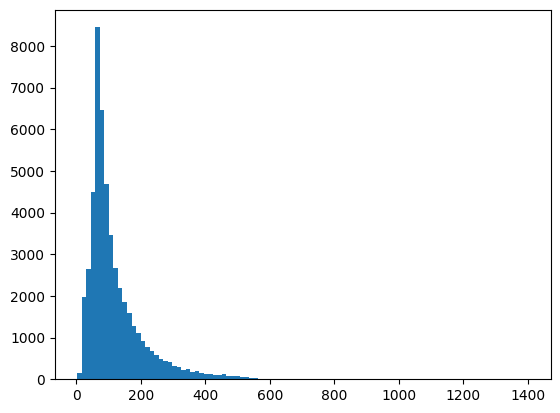

In [24]:
length_data = np.array([len(s) for s in sents_enc])

mean_length = np.mean(length_data)
max_length = np.max(length_data)
min_length = np.min(length_data)
std_length = np.std(length_data)

print("Mean length:", mean_length)
print("Max length:", max_length)
print("Min length:", min_length)
print("Standard deviation of length:", std_length)
plt.hist(length_data, bins=100)


## Padding data

In [25]:
max_len = 200
sents_pad = pad_sequences(sents_enc, maxlen=max_len, padding='post', truncating='post')
print("Shape of padded sequences:", sents_pad.shape)

Shape of padded sequences: (50000, 200)


In [26]:
check_reviews = sents_pad[:5]
tk.sequences_to_texts(check_reviews)

['one reviewers mentioned watching 1 oz episode hooked they right exactly happened me the thing struck oz brutality unflinching scenes violence set right word go trust me faint hearted timid this pulls punches regards drugs sex violence its hardcore classic use word it called oz nickname given oswald maximum security state penitentary it focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home many aryans muslims gangstas latinos christians italians irish more so scuffles death stares dodgy dealings shady agreements far away i main appeal fact goes shows dare forget pretty pictures painted mainstream audiences forget charm forget romance oz mess around the episode i saw struck nasty surreal i i ready it i watched more i developed taste oz got accustomed high levels graphic violence not violence injustice crooked guards sold nickel inmates kill order away it mannered middle class inmates turned prison bitches lack street sk

## Handle tokenize

### save tokenize

In [27]:
import pickle
tk_path = '../models/ws_1702/IMDB_tokenizer_3.pkl'

if os.path.exists(os.path.dirname(tk_path)):
    if os.path.exists(tk_path):
        print("The file is already exists.")
    else:
        with open(tk_path, 'wb') as handle:
            pickle.dump(tk, handle, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Tokenizer saved to {tk_path}")
else:
    print(f"Directory {os.path.dirname(tk_path)} does not exist. Please create it first.")

Tokenizer saved to ../models/ws_1702/IMDB_tokenizer_3.pkl


### load tokenize

In [28]:
with open(tk_path, 'rb') as handle:
    loaded_tk = pickle.load(handle)
    # del tk

## Prepare train & test data

In [29]:
from sklearn.model_selection import train_test_split

print("Shape of padded sequences:", sents_pad.shape)
print("Shape of labels:", df['label'].shape)

X_train, X_test, y_train, y_test = train_test_split(sents_pad, df['label'], test_size=.5, random_state=1)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of padded sequences: (50000, 200)
Shape of labels: (50000,)
Shape of X_train: (25000, 200)
Shape of X_test: (25000, 200)
Shape of y_train: (25000,)
Shape of y_test: (25000,)


In [30]:
print(X_train[:2])

[[    1    74     9  2122   864     1    86   207  2202     1    88   112
   2852  2965    10   728   720   363    32   638    22 12218   121  3005
    185   745  1889 11569   185   784   120    13   745  1889  2202   745
   1889    93  1889     1   723   642   115    72   452  1246    69   642
    105  4567    42  4893    72  1058   136   728   720  2579     5  4386
     29    90  3936  2579  1507   136   291  1056 31935     1  2251  3936
  54162  2565    42    93  2170    93  4184   331  8424    60   470  2398
   1419 39903    79  1432 69480 35251    49 69481 69482    53 22535    98
    102  1165    15  7544  1057  2561 15340     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0 

## Create embedding matrix

In [31]:
wv.index_to_key[:5]  # Check the first 5 words in the vocabulary

['the', ',', '.', 'of', 'to']

In [32]:
word_index = 200
word = wv.index_to_key[word_index]
print(f"The word corresponding to wv[{word_index}] is: {word}")
del word
wv[word_index]

The word corresponding to wv[200] is: according


array([-0.068258 , -0.047649 ,  0.49786  , -0.40922  , -0.0051759,
        0.012998 ,  0.38682  ,  0.16049  ,  0.13969  ,  0.3777   ,
        0.12385  , -0.32508  ,  0.76584  , -0.33999  , -0.032049 ,
       -0.58342  ,  0.53179  , -0.71871  , -0.88889  ,  0.095524 ,
        0.17448  , -0.4459   ,  0.19492  ,  0.71823  , -0.37576  ,
       -0.61964  ,  0.44474  , -0.5949   , -0.26213  ,  0.20811  ,
        0.13722  ,  0.033131 , -0.23305  , -0.0027318, -0.46937  ,
        0.47767  ,  0.25512  ,  0.53612  ,  0.045807 , -0.28083  ,
       -0.415    , -0.067618 , -0.26842  ,  0.36729  , -0.081097 ,
       -0.52428  , -0.2608   , -0.85743  , -0.76121  , -0.56286  ,
        0.7719   , -0.03485  ,  0.61521  ,  0.67937  ,  0.074163 ,
       -2.0818   , -0.26734  , -0.17753  ,  1.9872   ,  0.52471  ,
       -0.23144  ,  0.41671  ,  0.082092 , -0.18117  ,  0.56496  ,
        0.10529  , -0.24687  ,  0.42676  ,  0.90579  ,  0.10628  ,
       -0.26557  ,  0.36568  ,  0.19739  , -0.34528  ,  0.2225

In [33]:
wv.key_to_index
# wv.index_to_key

{'the': 0,
 ',': 1,
 '.': 2,
 'of': 3,
 'to': 4,
 'and': 5,
 'in': 6,
 'a': 7,
 '"': 8,
 "'s": 9,
 'for': 10,
 '-': 11,
 'that': 12,
 'on': 13,
 'is': 14,
 'was': 15,
 'said': 16,
 'with': 17,
 'he': 18,
 'as': 19,
 'it': 20,
 'by': 21,
 'at': 22,
 '(': 23,
 ')': 24,
 'from': 25,
 'his': 26,
 "''": 27,
 '``': 28,
 'an': 29,
 'be': 30,
 'has': 31,
 'are': 32,
 'have': 33,
 'but': 34,
 'were': 35,
 'not': 36,
 'this': 37,
 'who': 38,
 'they': 39,
 'had': 40,
 'i': 41,
 'which': 42,
 'will': 43,
 'their': 44,
 ':': 45,
 'or': 46,
 'its': 47,
 'one': 48,
 'after': 49,
 'new': 50,
 'been': 51,
 'also': 52,
 'we': 53,
 'would': 54,
 'two': 55,
 'more': 56,
 "'": 57,
 'first': 58,
 'about': 59,
 'up': 60,
 'when': 61,
 'year': 62,
 'there': 63,
 'all': 64,
 '--': 65,
 'out': 66,
 'she': 67,
 'other': 68,
 'people': 69,
 "n't": 70,
 'her': 71,
 'percent': 72,
 'than': 73,
 'over': 74,
 'into': 75,
 'last': 76,
 'some': 77,
 'government': 78,
 'time': 79,
 '$': 80,
 'you': 81,
 'years': 82,
 'i

In [34]:
tk.index_word[1]

'i'

### create matrix

In [35]:
embed_size = wv.vector_size # 100
print("Embedding size:", embed_size)

# Create an embedding matrix initialized with zeros (125499x100)
embedding_matrix = np.zeros((vocab_size, embed_size))

# Fill the embedding matrix with pre-trained word vectors
count = 0
for word, i in tk.word_index.items():
    if i >= vocab_size:
        continue
    try:
        embedding_vector = wv[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        # If the word is not in the pre-trained model, it will remain as zero
        embedding_matrix[i] = np.random.normal(0,np.sqrt(0.25), embed_size)
        print(f"Word '{word}' not found in pre-trained model. Using random vector.")
        count += 1


Embedding size: 100
Word '' not found in pre-trained model. Using random vector.
Word 'otoole' not found in pre-trained model. Using random vector.
Word '' not found in pre-trained model. Using random vector.
Word 'imho' not found in pre-trained model. Using random vector.
Word 'it´s' not found in pre-trained model. Using random vector.
Word 'gypo' not found in pre-trained model. Using random vector.
Word 'feinstone' not found in pre-trained model. Using random vector.
Word 'hynkel' not found in pre-trained model. Using random vector.
Word 'zelah' not found in pre-trained model. Using random vector.
Word 'amovie' not found in pre-trained model. Using random vector.
Word 'don´t' not found in pre-trained model. Using random vector.
Word 'cheezy' not found in pre-trained model. Using random vector.
Word 'ossessione' not found in pre-trained model. Using random vector.
Word 'carface' not found in pre-trained model. Using random vector.
Word 'taime' not found in pre-trained model. Using r

In [36]:
print(f"Number of words not found in pre-trained model: {count}")

Number of words not found in pre-trained model: 30925


### check embedding matrix

In [42]:
embedding_matrix[1]

array([-0.046539  ,  0.61966002,  0.56647003, -0.46584001, -1.18900001,
        0.44599   ,  0.066035  ,  0.31909999,  0.14679   , -0.22119001,
        0.79238999,  0.29905   ,  0.16073   ,  0.025324  ,  0.18678001,
       -0.31000999, -0.28108001,  0.60514998, -1.0654    ,  0.52476001,
        0.064152  ,  1.03579998, -0.40779001, -0.38011   ,  0.30801001,
        0.59964001, -0.26991001, -0.76034999,  0.94221997, -0.46919   ,
       -0.18278   ,  0.90652001,  0.79671001,  0.24824999,  0.25713   ,
        0.6232    , -0.44768   ,  0.65357   ,  0.76902002, -0.51229   ,
       -0.44332999, -0.21867   ,  0.38370001, -1.14830005, -0.94397998,
       -0.15062   ,  0.30012   , -0.57805997,  0.20175   , -1.65910006,
       -0.079195  ,  0.026423  ,  0.22051001,  0.99713999, -0.57538998,
       -2.72659993,  0.31448001,  0.70521998,  1.43809998,  0.99125999,
        0.13976   ,  1.34739995, -1.1753    ,  0.0039503 ,  1.02980006,
        0.064637  ,  0.90886998,  0.82871997, -0.47003001, -0.10

## Create model

In [43]:
X_train.shape[1]

200

### Bidirectional with GRU

In [52]:
model = Sequential(name='IMDB_GRUwith_Glove_model')
"""
vocab_size: Size of the vocabulary (number of unique words) from the tokenizer.
embed_size: Size of the embedding vectors (100 for GloVe 100-dimensional).
max_len: Maximum length of the input sequences (200 in this case).
embedding_matrix: Pre-trained embedding matrix containing GloVe vectors.
"""

model.add(Embedding(input_dim=vocab_size, output_dim=embed_size, input_shape=(max_len,),
                   weights=[embedding_matrix], trainable=True, name='Embedding_layer'))

model.add(Bidirectional(GRU(128, activation="tanh", name='GRU_layer1')))
model.add(Dense(1, activation='sigmoid', name='Output_layer'))
model.summary()

d:\Project\Learning\Environment_Project\tensorflow\tf-gpu-py310\lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "IMDB_GRUwith_Glove_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding_layer (Embedding)     │ (None, 200, 100)       │    10,670,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,846,897 (41.38 MB)

 Trainable params: 10,846,897 (41.38 MB)

 Non-trainable params: 0 (0.00 B)

### LSTM

In [80]:
model1 = Sequential(name='IMDB_GRUwith_Glove_model')

model1.add(Embedding(input_dim=vocab_size, output_dim=embed_size, input_shape=(max_len,),
                   weights=[embedding_matrix], trainable=True, name='Embedding_layer'))

model1.add(LSTM(units=128, activation='tanh'))
model1.add(Dense(1, activation='sigmoid', name='Output_layer'))
model1.summary()

d:\Project\Learning\Environment_Project\tensorflow\tf-gpu-py310\lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "IMDB_GRUwith_Glove_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding_layer (Embedding)     │ (None, 200, 100)       │    10,670,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,787,377 (41.15 MB)

 Trainable params: 10,787,377 (41.15 MB)

 Non-trainable params: 0 (0.00 B)

### Convolution layer

In [81]:
from tensorflow.keras.layers import Conv1D, Dropout, MaxPooling1D, GlobalMaxPool1D
model2 = Sequential()
model2.add(Embedding(input_dim=vocab_size, output_dim=embed_size, input_shape=(max_len,),
                   weights=[embedding_matrix], trainable=True, name='Embedding_layer'))
model2.add(Conv1D(128,5, activation='relu'))
model2.add(MaxPooling1D(5))
model2.add(Conv1D(128,5, activation='relu'))
model2.add(MaxPooling1D(5))
model2.add(Conv1D(128,5, activation='relu'))
model2.add(GlobalMaxPool1D())
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))

model2.add(Dense(1, activation='sigmoid'))
model2.summary()

d:\Project\Learning\Environment_Project\tensorflow\tf-gpu-py310\lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding_layer (Embedding)     │ (None, 200, 100)       │    10,670,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 35, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 3, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,914,865 (41.64 MB)

 Trainable params: 10,914,865 (41.64 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Define the callbacks
callback = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(filepath='../models/ws_1702/IMDB_GRU_Glove_model.h5', save_best_only=True)
]

## Compile model

In [58]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Train model

In [59]:
history = model.fit(X_train, y_train, epochs=7, batch_size=1024, validation_data=(X_test, y_test), verbose=1, callbacks=callback)

Epoch 1/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.5654 - loss: 0.6779

25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 857ms/step - accuracy: 0.5667 - loss: 0.6773 - val_accuracy: 0.6684 - val_loss: 0.6086
Epoch 2/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7172 - loss: 0.5505

25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 876ms/step - accuracy: 0.7184 - loss: 0.5491 - val_accuracy: 0.7951 - val_loss: 0.4644
Epoch 3/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8279 - loss: 0.4056

25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 910ms/step - accuracy: 0.8281 - loss: 0.4050 - val_accuracy: 0.8476 - val_loss: 0.3649
Epoch 4/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8767 - loss: 0.3061

25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 887ms/step - accuracy: 0.8769 - loss: 0.3057 - val_accuracy: 0.8680 - val_loss: 0.3194
Epoch 5/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9149 - loss: 0.2349

25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 915ms/step - accuracy: 0.9150 - loss: 0.2345 - val_accuracy: 0.8794 - val_loss: 0.3142
Epoch 6/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.9406 - loss: 0.1759

25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 863ms/step - accuracy: 0.9406 - loss: 0.1757 - val_accuracy: 0.8771 - val_loss: 0.3108
Epoch 7/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 866ms/step - accuracy: 0.9577 - loss: 0.1329 - val_accuracy: 0.8729 - val_loss: 0.3600


## Plotting loss and accuracy curve

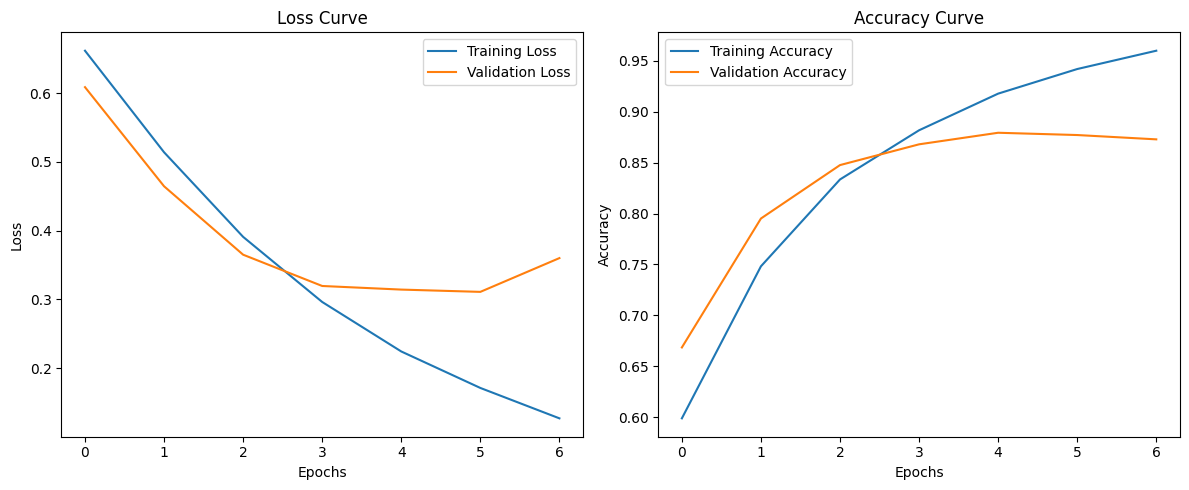

In [60]:
# Plotting loss and accuracy curves
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Prediction

In [75]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

comment1 = 'this film was about politics. i don\'t like it. It sucks. Can i get money back'
comment1 = expand_contractions(comment1)
word_tk = text_to_word_sequence(comment1) # cut word
word_tk 

['this',
 'film',
 'was',
 'about',
 'politics',
 'i',
 'do',
 'not',
 'like',
 'it',
 'it',
 'sucks',
 'can',
 'i',
 'get',
 'money',
 'back']

### encode

In [76]:
new_words_enc = tk.texts_to_sequences([comment1])
new_words_enc

[[9, 6, 79, 443, 2440, 1, 14, 7, 8, 5, 5, 1580, 917, 1, 948, 173, 481]]

### padding

In [77]:
X_new = pad_sequences(new_words_enc, truncating='post', padding='post', maxlen=max_len)
X_new

array([[   9,    6,   79,  443, 2440,    1,   14,    7,    8,    5,    5,
        1580,  917,    1,  948,  173,  481,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

### decode

In [78]:
print(tk.sequences_to_texts(X_new))

['this film was about politics i do not like it it sucks can i get money back']


### predict

In [79]:
result = model.predict(X_new)
print(np.squeeze(result).round(3))
print('Positive' if result[0] > 0.5 else 'Negative')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
0.244
Negative
